In [1]:
# Load Pandas library for data handling (CSV, tables)
import pandas as pd  

# Load NumPy for numerical operations
import numpy as np  

# Import TensorFlow (deep learning framework)
import tensorflow as tf  

# Import high-level API from TensorFlow
from tensorflow import keras  

# Import layers for building neural networks
from tensorflow.keras.layers import Embedding, LSTM, Dense  

# Import Sequential model (stack layers line-by-line)
from tensorflow.keras.models import Sequential  

In [3]:
# Read CSV file into a DataFrame
train = pd.read_csv("engtamilTrain.csv")  

# Drop unwanted column (usually index column from CSV)
train = train.drop(["Unnamed: 0"], axis=1)  

In [5]:
# Extract English sentences column
english_sentences = train["en"]  

# Extract Tamil sentences column
tamil_sentence = train['ta']  

In [7]:
# Take first 1000 English sentences (limit dataset size)
english_sentences = english_sentences.head(1000)  

# Take first 1000 Tamil sentences
tamil_sentences = tamil_sentence.head(1000)  

In [ ]:
# Import system module to access Python executable
#import sys  

# Install gensim library using current Python environment
#!"{sys.executable}" -m pip install gensim  

In [9]:
# Import Word2Vec model from gensim
from gensim.models import Word2Vec  

# Import PCA for dimensionality reduction
from sklearn.decomposition import PCA  

# Import plotting library
from matplotlib import pyplot  

In [ ]:
# Function: Tokenization

In [11]:
def sentToken(sentence):
    # Store dataset (list of sentences)
    dataset = sentence  

    # Convert each sentence into list of words
    sentences = [sentence.split() for sentence in dataset]  

    # Print tokenized sentences
    print(sentences)  

    # Return tokenized sentences
    return sentences  

In [15]:
# Tokenize English sentences
engSentence = sentToken(english_sentences)  

[['MMA', 'vice', 'president', 'Qazi', 'Hussain', 'Ahmad', 'declared', 'last', 'month:', "'We", 'are', 'not', 'extremists.'], ['Information', 'has', 'surfaced', 'in', 'recent', 'years', 'suggesting', 'that', 'Julius', 'Rosenberg', 'was', 'involved', 'in', 'passing', 'some', 'form', 'of', 'intelligence', 'to', 'Soviet', 'officials', 'during', 'the', 'Second', 'World', 'War.'], ['And', 'Azor', 'begat', 'Sadoc;', 'and', 'Sadoc', 'begat', 'Achim;', 'and', 'Achim', 'begat', 'Eliud;'], ['She', 'says', 'she', 'knows', 'what', 'is', 'going', 'on,', 'but', 'can', 'do', 'nothing', 'about', 'it.'], ['And', 'be', 'it', 'indeed', 'that', 'I', 'have', 'erred,', 'my', 'error', 'remains', 'with', 'myself.'], ['Finally,', 'the', 'columnist', 'fails', 'to', 'tell', 'us', 'who', 'among', 'the', 'political', 'leaders', 'of', 'the', 'bourgeoisie,', 'past', 'and', 'present,', 'he', 'counts', 'among', 'the', 'paragons', 'of', 'morality.'], ['These', 'include', 'the', 'British', 'Tamil', 'Forum,', 'La', 'Maiso

In [17]:
# Tokenize Tamil sentences
tamSentence = sentToken(tamil_sentences)  

[['MMA', 'கட்சியின்', 'துணைத்தலைவர்', 'க்வாஸி', 'ஹுசேன்', 'அகமத்', 'சென்ற', 'மாதம்', 'பின்வருமாறு', 'அறிவித்தார்:', '``நாங்கள்', 'தீவிரவாதிகள்', 'அல்ல.'], ['சமீபகாலத்தில்', 'சில', 'தகவல்கள்', 'யூலியஸ்', 'ரோசன்பேர்க்', 'ஒரு', 'வித', 'உளவுச்செய்தியை', 'சோவியத்', 'அதிகாரிகளுக்கு', 'இரண்டாம்', 'உலகப்போரின்போது', 'அனுப்பியதில்', 'சம்பந்தப்பட்டு', 'இருந்ததாக', 'வெளிவந்துள்ளன.'], ['ஆசோர்', 'சாதோக்கைப்', 'பெற்றான்;', 'சாதோக்கு', 'ஆகீமைப்', 'பெற்றான்;', 'ஆகீம்', 'எலியூதைப்', 'பெற்றான்;'], ['என்ன', 'நடக்கிறது', 'என்பது', 'தமக்கு', 'தெரியும்', 'என்றும்', 'ஆனால்,', 'தம்மால்', 'எதுவும்', 'செய்யமுடியாது', 'என்றும்', 'கடிதம்', 'எழுதியிருந்தார்.'], ['நான்', 'தப்பிநடந்தது', 'மெய்யானாலும்,', 'என்', 'தப்பிதம்', 'என்னோடேதான்', 'இருக்கிறது'], ['டால்ரிம்பிளினுடைய', 'அறிவுஜீவித்', 'தொடுவானத்திற்கு', 'அப்பால்', 'எவ்வளவோ', 'தொலைவில்', 'இருந்தன'], ['இந்த', 'அமைப்புக்களில்', 'British', 'Tamil', 'Forum,', 'La', 'Maison', 'du', 'Tamil', 'Eelam', '(France),', 'the', 'Canadian', 'Tamil', 'Congress,', 'Swiss',

In [ ]:
# Function: Train Word2Vec Model

In [19]:
def ownWordModel(langsentence,modelname):
    # Import again (not necessary but safe inside function)
    from gensim.models import Word2Vec
    # Import PCA
    from sklearn.decomposition import PCA
    # Import plotting
    import matplotlib.pyplot as plt
    # Train Word2Vec model
    model = Word2Vec(langsentence, min_count=1)
    print(model)
    # save model
    model.save(modelname)
    # fit a 2d PCA model to the vectors
    X = model.wv.vectors  # corrected line
    pca = PCA(n_components=2)
    result = pca.fit_transform(X)

    # create a scatter plot of the projection
    plt.scatter(result[:, 0], result[:, 1])
    words = list(model.wv.index_to_key)
    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]))
    plt.show()

Word2Vec<vocab=7300, vector_size=100, alpha=0.025>


C:\Users\Mohamed Roomy\.conda\envs\my_v_dl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Mohamed Roomy\.conda\envs\my_v_dl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Mohamed Roomy\.conda\envs\my_v_dl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Mohamed Roomy\.conda\envs\my_v_dl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


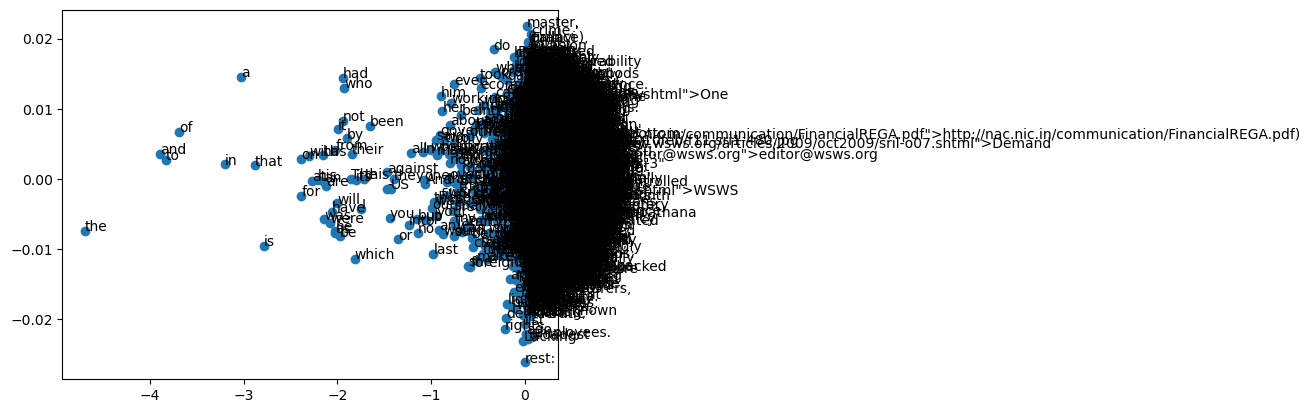

In [21]:
# Train model for English and save it
ownWordModel(engSentence, "engmodel.bin")  

In [ ]:
# Train model for Tamil and save it
ownWordModel(tamSentence, "tammodel.bin")  